In [2]:
import re
import sys
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from pathlib import Path

import config
from gene_selectors import GeneSelector
from pipeline import data_prep, enrichment, plots
from pipeline.enrichment import gsea_run_dir, run_gsea_prerank
from viz_style import apply_style
apply_style()

In [3]:
dd = data_prep.load_disease_filtered() # Filter disease phenotype with OOD covariate distribution & too small samples sizes.
print(f'Final: {dd.Z_dis.shape[0]} samples, {len(np.unique(dd.dis_pheno))} phenotypes')

Final: 854 samples, 20 phenotypes


In [4]:
print(pd.Series(dd.dis_pheno).value_counts().to_string())

CAD_HF+                          112
Tuberculosis                     101
CAD_HF-                          100
ME/CFS                            90
Pancreatitis                      79
Pancreatic Cancer (Moore)         72
Pre-eclampsia                     59
Colorectal Cancer                 37
Lung Cancer                       30
Liver Cancer (Roskams-Hieter)     28
Esophagus Cancer (Chen)           25
Stomach Cancer                    24
MM                                17
Other Cancer                      16
HIV                               13
ICI-m                             11
ICI-treated Cancer                11
HIV + Tuberculosis                11
Liver Cancer (Chen)               10
MGUS                               8


In [38]:
FILTER_CONDITIONS = [
    {'ubiquity_thr': None,  'ubiquity_abs_z': 0.5, 'label': 'no_filter'},
    {'ubiquity_thr': 0.5,   'ubiquity_abs_z': 0.5, 'label': 'ubiq50_abs5'},
    {'ubiquity_thr': 0.6,   'ubiquity_abs_z': 0.5, 'label': 'ubiq60_abs5'},
    {'ubiquity_thr': 0.7,   'ubiquity_abs_z': 0.5, 'label': 'ubiq70_abs5'},
]

for cond in FILTER_CONDITIONS:
    cond['gsea_dir'] = gsea_run_dir(cond['ubiquity_thr'], cond['ubiquity_abs_z'])
    print(f"{cond['label']:15s} → {cond['gsea_dir'].relative_to(config.ROOT)}")

no_filter       → Modeling/GSEA/no_filter
ubiq50_abs5     → Modeling/GSEA/ubiq50_abs5
ubiq60_abs5     → Modeling/GSEA/ubiq60_abs5
ubiq70_abs5     → Modeling/GSEA/ubiq70_abs5


## Ubiquity filter: target gene identification

Compute cross-disease ubiquity scores and identify which genes each condition zeros out in the GSEA ranking. Compare against known artifact-candidate families (ribo, OXPHOS, histone).

In [39]:
HISTONE_PAT = re.compile(r'^HIST[0-9]|^H[0-9][A-Z][A-Z0-9]|^H[0-9]-', re.I)
OXPHOS_PAT  = re.compile(r'^NDUF|^COX[0-9]|^ATP5|^UQCR|^SDHA|^SDHB|^SDHC|^SDHD')
RIBO_PAT    = re.compile(r'^RPS[0-9]|^RPL[0-9]|^RPLP')

def classify(s):
    if OXPHOS_PAT.match(s):  return 'oxphos'
    if RIBO_PAT.match(s):    return 'ribo'
    if HISTONE_PAT.match(s): return 'histone'
    return 'other'

gs = GeneSelector(dd.Z_dis, dd.dis_pheno, dd.gene_syms)
gene_cat = np.array([classify(s) for s in dd.gene_syms])

ubiq_rows = []
for cond in FILTER_CONDITIONS:
    thr = cond['ubiquity_thr']
    abs_z = cond['ubiquity_abs_z']
    if thr is None:
        ubiq_rows.append({'label': cond['label'], 'n_zeroed': 0,
                          'oxphos': 0, 'ribo': 0, 'histone': 0, 'other': 0})
        continue
    ubiq = gs.compute_ubiquity(abs_z_thr=abs_z)
    mask = ubiq >= thr
    ubiq_rows.append({
        'label':   cond['label'],
        'n_zeroed': int(mask.sum()),
        'oxphos':  int((mask & (gene_cat == 'oxphos')).sum()),
        'ribo':    int((mask & (gene_cat == 'ribo')).sum()),
        'histone': int((mask & (gene_cat == 'histone')).sum()),
        'other':   int((mask & (gene_cat == 'other')).sum()),
    })

ubiq_df = pd.DataFrame(ubiq_rows).set_index('label')
print('=== Genes zeroed out per filter condition ===')
print(ubiq_df.to_string())

n_oxphos = (gene_cat == 'oxphos').sum()
n_ribo   = (gene_cat == 'ribo').sum()
n_hist   = (gene_cat == 'histone').sum()
print(f'\nTotal genes in model: {len(dd.gene_syms)}')
print(f'Artifact-candidate families in model: oxphos={n_oxphos}, ribo={n_ribo}, histone={n_hist}')

=== Genes zeroed out per filter condition ===
             n_zeroed  oxphos  ribo  histone  other
label                                              
no_filter           0       0     0        0      0
ubiq50_abs5      1597      31    59       23   1484
ubiq60_abs5       523      15    27        4    477
ubiq70_abs5       131       6     9        2    114

Total genes in model: 20097
Artifact-candidate families in model: oxphos=111, ribo=100, histone=96


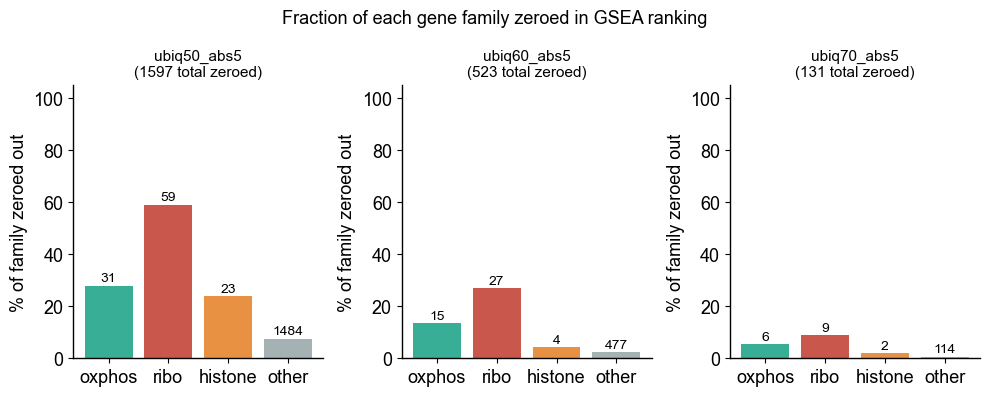

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(FILTER_CONDITIONS) - 1, figsize=(10, 4), sharey=False)
cats = ['oxphos', 'ribo', 'histone', 'other']
colors = ['#16a085', '#c0392b', '#e67e22', '#95a5a6']

for ax, cond in zip(axes, [c for c in FILTER_CONDITIONS if c['ubiquity_thr'] is not None]):
    row = ubiq_df.loc[cond['label']]
    totals = [row[c] for c in cats]
    totals_pct = [row[c] / max(
        (gene_cat == c).sum(), 1) * 100 for c in cats]
    bars = ax.bar(cats, totals_pct, color=colors, alpha=0.85, edgecolor='none')
    for bar, n in zip(bars, totals):
        if n > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    str(n), ha='center', va='bottom', fontsize=10)
    ax.set_title(f"{cond['label']}\n({row['n_zeroed']} total zeroed)", fontsize=11)
    ax.set_ylabel('% of family zeroed out')
    ax.set_ylim(0, 105)

plt.suptitle('Fraction of each gene family zeroed in GSEA ranking', fontsize=13)
plt.tight_layout()
plt.show()

## GSEA run — all filter conditions

Run GSEA prerank for each condition and save to the corresponding directory. Skip if results already exist.

In [41]:
from pipeline.signatures import load_gsea

all_results = {}
unique_phenos = np.unique(dd.dis_pheno)

for cond in FILTER_CONDITIONS:
    label = cond['label']
    gsea_dir = cond['gsea_dir']
    thr = cond['ubiquity_thr']
    abs_z = cond['ubiquity_abs_z']

    existing = list(gsea_dir.glob('gsea_result_*.csv'))
    if existing:
        print(f"[{label}] loading {len(existing)} files from {gsea_dir.relative_to(config.ROOT)}")
        loaded = {}
        for ph in unique_phenos:
            df = load_gsea(ph, gsea_dir=gsea_dir)
            if df is not None:
                loaded[ph] = df
        all_results[label] = loaded
        print(f"  loaded: {len(loaded)}/{len(unique_phenos)} phenotypes")
        continue

    if thr is None:
        print(f"[{label}] no existing results found — run with ubiquity_thr=None first to generate baseline")
        all_results[label] = {}
        continue

    print(f"\n{'='*60}")
    print(f"[{label}] Running GSEA → {gsea_dir.relative_to(config.ROOT)}")
    print(f"{'='*60}")
    results = run_gsea_prerank(
        dd.Z_dis, dd.dis_pheno, dd.gene_syms,
        outdir=gsea_dir,
        ubiquity_thr=thr,
        ubiquity_abs_z=abs_z,
    )
    all_results[label] = results
    print(f"[{label}] Done — {len(results)} phenotypes written")

[no_filter] loading 22 files from Modeling/GSEA/no_filter
  loaded: 20/20 phenotypes
[ubiq50_abs5] loading 20 files from Modeling/GSEA/ubiq50_abs5
  loaded: 20/20 phenotypes
[ubiq60_abs5] loading 20 files from Modeling/GSEA/ubiq60_abs5
  loaded: 20/20 phenotypes
[ubiq70_abs5] loading 20 files from Modeling/GSEA/ubiq70_abs5
  loaded: 20/20 phenotypes


## Dotplots — save per condition

Save up/down dotplots for each filter condition into `{gsea_dir}/Figures/gsea_dotplot/`.

In [42]:
sample_sizes = {ph: int((dd.dis_pheno == ph).sum()) for ph in unique_phenos}

for cond in FILTER_CONDITIONS:
    label = cond['label']
    gsea_dir = cond['gsea_dir']
    fig_dir = gsea_dir / 'Figures' / 'gsea_dotplot'

    results = all_results.get(label, {})
    if not results:
        print(f"[{label}] no results — skipping plots")
        continue

    print(f"[{label}] saving dotplots → {fig_dir.relative_to(config.ROOT)}")
    plots.plot_gsea_dotplots(results, fig_dir=fig_dir, sample_sizes=sample_sizes)

[no_filter] saving dotplots → Modeling/GSEA/no_filter/Figures/gsea_dotplot
[CAD_HF+] GSEA Plots generated successfully.
[CAD_HF-] GSEA Plots generated successfully.
[Colorectal Cancer] GSEA Plots generated successfully.
[Esophagus Cancer (Chen)] GSEA Plots generated successfully.
[HIV] GSEA Plots generated successfully.
[HIV + Tuberculosis] GSEA Plots generated successfully.
[ICI-m] GSEA Plots generated successfully.
[ICI-treated Cancer] GSEA Plots generated successfully.
[Liver Cancer (Chen)] GSEA Plots generated successfully.
[Liver Cancer (Roskams-Hieter)] GSEA Plots generated successfully.
[Lung Cancer] GSEA Plots generated successfully.
[ME/CFS] GSEA Plots generated successfully.
[MGUS] GSEA Plots generated successfully.
[MM] GSEA Plots generated successfully.
[Other Cancer] GSEA Plots generated successfully.
[Pancreatic Cancer (Moore)] GSEA Plots generated successfully.
[Pancreatitis] GSEA Plots generated successfully.
[Pre-eclampsia] GSEA Plots generated successfully.
[Stomach C

## Cross-condition comparison

Compare the GSEA results across filter conditions:
- Total significant terms (NES>0 / NES<0)
- Artifact-candidate pathway terms (OXPHOS, ribo, histone keywords)
- Per-phenotype term count change

In [43]:
import re as _re

ARTIFACT_PAT = _re.compile(
    r'histone|chromatin|nucleosome'
    r'|mitochond|oxidative phosph|electron transport|respiratory chain'
    r'|ribosom|rRNA|translation elongation|translation initiation',
    _re.IGNORECASE,
)

def summarise_results(results):
    rows = []
    for ph, df in results.items():
        df = df.copy()
        df['NES'] = pd.to_numeric(df['NES'], errors='coerce')
        n_up   = int((df['NES'] > 0).sum())
        n_dn   = int((df['NES'] < 0).sum())
        n_art  = int(df['Term'].str.contains(ARTIFACT_PAT, na=False).sum())
        rows.append({'phenotype': ph, 'n_up': n_up, 'n_dn': n_dn,
                     'n_total': n_up + n_dn, 'n_artifact': n_art})
    return pd.DataFrame(rows).set_index('phenotype').sort_index()

summaries = {label: summarise_results(res) for label, res in all_results.items()}

print('=== Total significant terms per condition ===')
totals = pd.DataFrame({
    label: s['n_total'] for label, s in summaries.items()
})
totals.loc['TOTAL'] = totals.sum()
print(totals.to_string())

print()
print('=== Artifact-candidate pathway terms per condition ===')
arts = pd.DataFrame({
    label: s['n_artifact'] for label, s in summaries.items()
})
arts.loc['TOTAL'] = arts.sum()
print(arts.to_string())

=== Total significant terms per condition ===
                               no_filter  ubiq50_abs5  ubiq60_abs5  ubiq70_abs5
phenotype                                                                      
CAD_HF+                              961         1142         1052          985
CAD_HF-                              922          965          935          896
Colorectal Cancer                    385          339          348          388
Esophagus Cancer (Chen)              683          595          624          661
HIV                                  482          280          443          365
HIV + Tuberculosis                   397          313          426          405
ICI-m                                479          337          498          476
ICI-treated Cancer                  1304         1212         1189         1259
Liver Cancer (Chen)                  625          453          569          617
Liver Cancer (Roskams-Hieter)        217          280          306        

KeyError: 'no_filter'

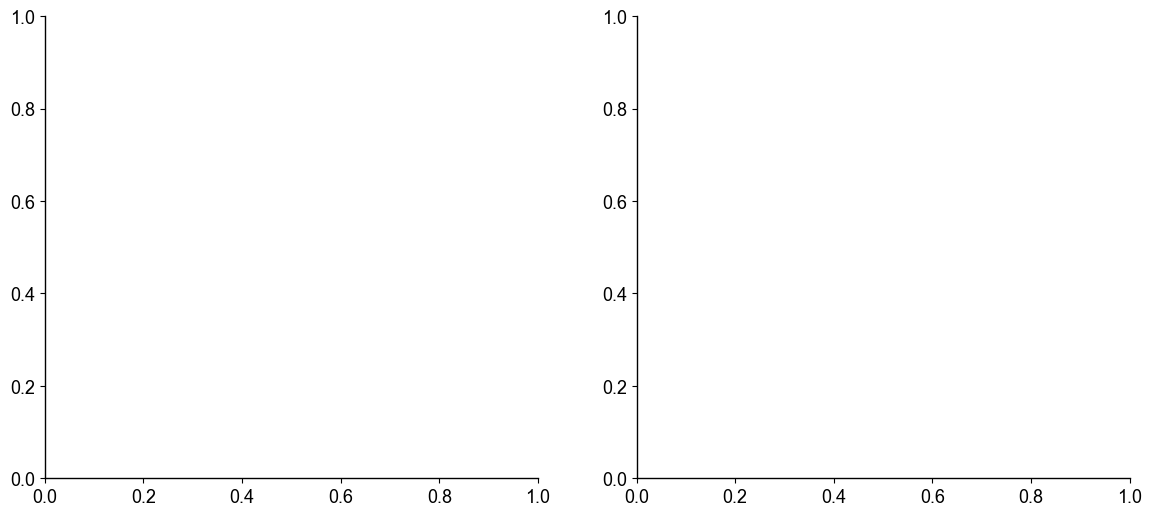

In [ ]:
ref_label = FILTER_CONDITIONS[0]['label']
ref = summaries[ref_label]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in [
    (axes[0], 'n_total',    'Total significant terms'),
    (axes[1], 'n_artifact', 'Artifact-candidate terms'),
]:
    x = np.arange(len(ref))
    width = 0.8 / len(FILTER_CONDITIONS)
    for i, cond in enumerate(FILTER_CONDITIONS):
        label = cond['label']
        vals = summaries[label][col].values
        bars = ax.bar(x + i * width, vals, width, label=label, alpha=0.85)

    ax.set_xticks(x + width * (len(FILTER_CONDITIONS) - 1) / 2)
    ax.set_xticklabels(ref.index, rotation=40, ha='right', fontsize=8)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('GSEA term counts across filter conditions', fontsize=14)
plt.tight_layout()
plt.show()

print('\n=== Change vs no_filter (delta = condition - no_filter) ===')
delta = pd.DataFrame({
    label: summaries[label]['n_total'] - ref['n_total']
    for label in [c['label'] for c in FILTER_CONDITIONS[1:]]
})
delta.loc['TOTAL'] = delta.sum()
print(delta.to_string())